### Instalación y carga de dependencias

In [570]:
%pip install matplotlib python-doctr[torch]

import re, json
import logging
from datetime import date
from dataclasses import dataclass, field
from typing import Optional, List
import matplotlib.pyplot as plt
from matplotlib import patches
import matplotlib.image as mpimg
from doctr.io import DocumentFile
from doctr.models import ocr_predictor

Note: you may need to restart the kernel to use updated packages.


In [571]:
logging.basicConfig(level=logging.DEBUG)

logger = logging.getLogger(__name__)
logger.setLevel(logging.INFO)

### Clases de datos
Definimos estructuras (`@dataclass`) para almacenar los resultados de forma consistente.

- `FrontData`: campos extraídos del **anverso** (nombre, apellidos, sexo, fechas…).
- `MRZData`: campos extraídos del **Machine Reading Zone** (estándar ICAO 9303 TD1) + checksums.
- `DNIResult`: objeto final unificado que contiene:
  - datos del anverso + datos MRZ
  - métricas de calidad (confianza OCR, caducidad, flags de riesgo, etc.)

In [572]:
@dataclass
class MRZData:
    raw_lines: List[str] = field(default_factory=list)
    document_type: str = ""
    country_code: str = ""
    document_number: str = ""
    doc_check_valid: bool = False
    optional_data_1: str = ""
    birth_date: str = ""
    birth_check_valid: bool = False
    sex: str = ""
    expiry_date: str = ""
    expiry_check_valid: bool = False
    nationality: str = ""
    optional_data_2: str = ""
    composite_check_valid: bool = False
    surname: str = ""
    given_names: str = ""
    all_checksums_valid: bool = False

In [573]:
@dataclass
class FrontData:
    dni_number: str = ""
    surname: str = ""
    given_names: str = ""
    sex: str = ""
    nationality: str = ""
    birth_date: str = ""
    issue_date: str = ""
    expiry_date: str = ""
    support_number: str = ""

In [574]:
@dataclass
class DNIResult:
    dni_number: str = ""
    surname: str = ""
    given_names: str = ""
    full_name: str = ""
    sex: str = ""
    nationality: str = ""
    birth_date: str = ""
    issue_date: str = ""
    expiry_date: str = ""
    domicilio: str = ""
    lugar_nacimiento: str = ""
    padres: str = ""
    support_number: str = ""
    front: Optional[FrontData] = None
    mrz: Optional[MRZData] = None
    # Análisis
    ocr_confidence_front: float = 0.0
    ocr_confidence_back: float = 0.0
    dni_letter_valid: Optional[bool] = None
    document_expired: Optional[bool] = None
    days_to_expiry: Optional[int] = None
    data_completeness: float = 0.0
    cross_validation: dict = field(default_factory=dict)
    risk_flags: List[str] = field(default_factory=list)
    quality_score: float = 0.0
    raw_front_text: List[str] = field(default_factory=list)
    raw_back_text: List[str] = field(default_factory=list)

### Visualización OCR con matplotlib
Funciones auxiliares para inspeccionar el OCR visualmente.

- `show_ocr`: dibuja bounding boxes sobre la imagen, variando su color en función de la confianza.
- `show_confidence_chart`: muestra la confianza por palabra en forma de gráfico de barras.

In [575]:
def show_ocr(result, img_path, title="OCR"):
    """Muestra la imagen con bounding boxes coloreados por confianza y texto con %"""
    img = mpimg.imread(img_path)
    h, w = img.shape[:2]

    for page in result.pages:
        fig, ax = plt.subplots(1, figsize=(14, 10))
        ax.imshow(img)
        ax.set_title(title, fontsize=14, fontweight='bold')

        for block in page.blocks:
            for line in block.lines:
                for word in line.words:
                    (x1, y1), (x2, y2) = word.geometry
                    # Coordenadas normalizadas → píxeles
                    px1, py1, px2, py2 = x1*w, y1*h, x2*w, y2*h
                    conf = word.confidence

                    # Color según confianza: verde (alta) → amarillo → rojo (baja)
                    if conf >= 0.8:
                        color = '#2ecc71'      # verde
                    elif conf >= 0.5:
                        color = '#f39c12'      # naranja
                    else:
                        color = '#e74c3c'      # rojo

                    rect = patches.Rectangle(
                        (px1, py1), px2-px1, py2-py1,
                        linewidth=1.5, edgecolor=color, facecolor=color, alpha=0.15)
                    ax.add_patch(rect)
                    ax.plot([px1, px2, px2, px1, px1], [py1, py1, py2, py2, py1],
                            color=color, linewidth=1.2)
                    ax.text(px1, py1-3, f"{word.value} ({conf:.0%})",
                            fontsize=6, color=color, fontweight='bold',
                            va='bottom', bbox=dict(boxstyle='round,pad=0.1',
                            facecolor='white', alpha=0.7, edgecolor='none'))

        ax.axis('off')
        plt.tight_layout()
        plt.show()

In [576]:
def show_confidence_chart(result, title="Confianza por palabra"):
    """Gráfico de barras con la confianza de cada palabra detectada"""
    words, confs = [], []
    for page in result.pages:
        for block in page.blocks:
            for line in block.lines:
                for w in line.words:
                    words.append(w.value)
                    confs.append(w.confidence * 100)

    if not words:
        return

    fig, ax = plt.subplots(figsize=(14, max(4, len(words) * 0.25)))
    colors = ['#2ecc71' if c >= 80 else '#f39c12' if c >= 50 else '#e74c3c' for c in confs]
    y_pos = range(len(words))

    ax.barh(y_pos, confs, color=colors, edgecolor='white', height=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(words, fontsize=7, fontfamily='monospace')
    ax.set_xlabel('Confianza (%)')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlim(0, 105)
    ax.invert_yaxis()

    # Líneas de referencia
    ax.axvline(x=80, color='#2ecc71', linestyle='--', alpha=0.4, label='Alta (80%)')
    ax.axvline(x=50, color='#f39c12', linestyle='--', alpha=0.4, label='Media (50%)')
    ax.legend(loc='lower right', fontsize=8)

    for i, c in enumerate(confs):
        ax.text(c + 0.5, i, f'{c:.0f}%', va='center', fontsize=6, fontweight='bold')

    plt.tight_layout()
    plt.show()

### OCR
Wrapper para el OCR:
- `ocr_image`: devuelve el resultado puro del OCR para la imagen
- `get_lines`: devuelve el resultado depurado, en función de un umbral de confianza
  - Si este umbral es muy alto, pierdes información, si es muy bajo, pasa mucho ruido

In [577]:
def ocr_image(path):
    model = ocr_predictor(pretrained=True)
    return model(DocumentFile.from_images(path))

In [578]:
def get_lines(result, min_conf=0.2):
    """Devuelve lista de (texto_linea, confianza_media)"""
    data = []
    for page in result.pages:
        for block in page.blocks:
            for line in block.lines:
                words = [(w.value, w.confidence) for w in line.words if w.confidence >= min_conf]
                if words:
                    data.append((' '.join(w for w, _ in words),
                                 sum(c for _, c in words) / len(words)))
    return data

### Utils
Utilidades generales usadas en varios puntos:

- `clean_mrz`: filtra caracteres, dejando solo alfanuméricos y '<'.
- `norm_name`: normalización de nombres (mayúsculas, quitar rellenos, espacios).
- `levenshtein`: devuelve la distancia de edición entre dos cadenas.

In [579]:
def clean_mrz(line):
    """Deja solo A-Z, 0-9, <"""
    return re.sub(r'[^A-Z0-9<]', '', line.upper().replace(' ', ''))

In [580]:
def norm_name(name):
    """GARCIA<LOPEZ → Garcia Lopez"""
    return re.sub(r'\s+', ' ', re.sub(r'<+', ' ', name)).strip().title()

In [581]:
def levenshtein(s1, s2):
    if len(s1) < len(s2): return levenshtein(s2, s1)
    if not s2: return len(s1)
    prev = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        curr = [i + 1]
        for j, c2 in enumerate(s2):
            curr.append(min(prev[j+1]+1, curr[j]+1, prev[j]+(0 if c1==c2 else 1)))
        prev = curr
    return prev[-1]

### Validación letra DNI/NIE
Validación del dígito/letra de control del DNI/NIE:

- El DNI usa un algoritmo de módulo 23 con una tabla fija de letras.
- Si el OCR lee mal un dígito, esta validación suele detectar el error.

Devuelve `True/False` indicando si el número capturado es consistente.

In [582]:
DNI_LETTERS = "TRWAGMYFPDXBNJZSQVHLCKE"

def validate_dni_letter(dni):
    if not dni: return False
    try:
        n = dni[:-1]
        if n[0] in 'XYZ': n = str('XYZ'.index(n[0])) + n[1:]
        return dni[-1].upper() == DNI_LETTERS[int(n) % 23]
    except (ValueError, IndexError):
        return False

### Parsing y validaciones de la MRZ
Implementación de parsing y validaciones de la MRZ para documentos tipo TD1 (tarjeta ID).

Características TD1:
- 3 líneas
- 30 caracteres por línea

Incluye:
- checksum por campo (número doc, fecha nacimiento, fecha caducidad…)
- checksum compuesto (composite) que resume varias partes

Si los checksums salen correctos, normalmente significa que:
- el OCR leyó bien la MRZ
- o al menos el error es poco probable (reduce falsos positivos)

In [583]:
MRZ_W = [7, 3, 1]
MRZ_V = {'<': 0}
MRZ_V.update({str(i): i for i in range(10)})
MRZ_V.update({chr(65+i): 10+i for i in range(26)})

In [584]:
def mrz_check(data, digit):
    try:
        mrz_checksum = sum(MRZ_V.get(c.upper(), 0) * MRZ_W[i % 3] for i, c in enumerate(data)) % 10 
        return str(mrz_checksum) == digit
    except: return False

In [585]:
def parse_mrz_date(raw):
    """YYMMDD → DD/MM/YYYY"""
    try:
        y, m, d = int(raw[:2]), int(raw[2:4]), int(raw[4:6])
        return f"{d:02d}/{m:02d}/{1900+y if y > 30 else 2000+y}"
    except: return ""

In [586]:
def detect_mrz_lines(lines):
    """Busca las 3 líneas MRZ TD1 clasificando por patrón (no por orden)"""
    cands = [clean_mrz(l) for l in lines]
    cands = [c for c in cands if len(c) >= 25 and re.match(r'^[A-Z0-9<]{25,}$', c)]
    if not cands: return []

    l1 = l2 = l3 = None
    for c in cands:
        p = (c + '<'*30)[:30]
        if not l1 and p[0] in 'IAC' and re.match(r'^[IAC][A-Z<]', p):
            l1 = p
        elif not l2 and re.match(r'^\d{6}', p) and p[7] in 'MF<':
            l2 = p
        elif not l3 and '<<' in c:
            l3 = (c + '<'*30)[:30]
    return [l for l in (l1, l2, l3) if l]

In [587]:
def clean_mrz_line(line):
    s = re.sub(r'[^A-Z0-9<]', '', line.upper().replace(' ', ''))
    return s[:30].ljust(30, '<')

In [588]:
def mrz_char_value(c):
    if c.isdigit():
        return int(c)
    if c == '<':
        return 0
    return ord(c) - 55  # A=10 ... Z=35

In [589]:
def mrz_checksum(field: str) -> str:
    weights = [7, 3, 1]
    total = 0
    for i, ch in enumerate(field):
        total += mrz_char_value(ch) * weights[i % 3]
    return str(total % 10)

In [590]:
def validate_td1_checksums(line1: str, line2: str) -> bool:
    line1 = clean_mrz_line(line1)
    line2 = clean_mrz_line(line2)

    # TD1 posiciones oficiales
    doc_number = line1[5:14]
    doc_check = line1[14]

    birth_date = line2[0:6]
    birth_check = line2[6]

    expiry_date = line2[8:14]
    expiry_check = line2[14]

    composite_field = (
        line1[5:30] +
        line2[0:7] +
        line2[8:15]
    )
    composite_check = line2[29]

    return (
        mrz_checksum(doc_number) == doc_check and
        mrz_checksum(birth_date) == birth_check and
        mrz_checksum(expiry_date) == expiry_check and
        mrz_checksum(composite_field) == composite_check
    )

In [591]:
def build_td1_line3_from_front(surname: str, given_names: str) -> str:
    def norm(x):
        x = x.upper()
        x = re.sub(r'[^A-Z ]', '', x)
        x = re.sub(r'\s+', ' ', x).strip()
        return x.replace(' ', '<')

    sur = norm(surname)
    giv = norm(given_names)

    line = f"{sur}<<{giv}"
    return (line + '<'*30)[:30]

In [592]:
def rebuild_td1_line1_with_front(l1: str, front) -> str:
    """
    Reconstruye L1 TD1 si OCR se comió caracteres.
    Formato TD1:
      [0:2] doc type      -> 'ID'
      [2:5] issuer        -> 'ESP'
      [5:14] doc number   -> 9 chars
      [14]  doc check     -> 1 digit
      [15:30] optional    -> suele contener DNI/NIE, etc.
    """
    l1 = clean_mrz_line(l1)

    if not front:
        return l1

    issuer = l1[2:5] if l1[2:5].replace('<','') else 'ESP'
    doc_type = l1[0:2] if l1[0:2].replace('<','') else 'ID'

    support = (getattr(front, "support_number", "") or "").upper()
    support = re.sub(r'[^A-Z0-9]', '', support)

    dni = (getattr(front, "dni_number", "") or "").upper()
    dni = re.sub(r'[^A-Z0-9]', '', dni)

    # Si no tengo soporte, no puedo reconstruir el doc number bien
    if len(support) < 5:
        return l1

    # Doc number TD1 son 9 chars: si tu soporte trae 9, perfecto.
    doc_number = support[:9].ljust(9, '<')

    # Check digit calculado (esto es lo importante)
    doc_check = mrz_checksum(doc_number)

    optional = (dni + '<' * 30)[:15]  # 15 chars para completar hasta 30 total
    rebuilt = f"{doc_type}{issuer}{doc_number}{doc_check}{optional}"
    return rebuilt[:30].ljust(30, '<')

In [593]:
def fix_mrz_with_front(mrz_lines, surname, given_names):
    line1 = clean_mrz_line(mrz_lines[0])
    line2 = clean_mrz_line(mrz_lines[1])
    line3 = clean_mrz_line(mrz_lines[2])

    # Si línea 3 parece mala (pocos '<' o sin separador fuerte)
    if line3.count('<') < 3 or '<<' not in line3:
        line3 = build_td1_line3_from_front(surname, given_names)

    checksums_ok = validate_td1_checksums(line1, line2)

    return [line1, line2, line3], checksums_ok

In [594]:
def expiry_from_mrz(line2: str):
    line2 = clean_mrz_line(line2)
    expiry = line2[8:14]  # YYMMDD

    year = int(expiry[0:2])
    month = int(expiry[2:4])
    day = int(expiry[4:6])

    # regla simple para siglo
    year += 2000 if year < 50 else 1900

    return f"{day:02d}/{month:02d}/{year}"

### Corrección OCR en línea de nombres del MRZ
La línea de nombres del MRZ suele ser donde más falla el OCR por:
- rellenos con `<`
- nombres compuestos
- caracteres pegados o ruido

Aquí aplicamos:
- heurísticas + fuzzy matching
- comparación con el anverso (si lo tenemos) para corregir apellidos/nombres
- normalización de tokens

Meta: que `surname` y `given_names` del MRZ se acerquen a los del anverso.
El OCR a veces lee '<' como S, K o X, rompiendo los separadores


In [595]:
# ---------------------------
# MRZ helpers (TD1)
# ---------------------------

MRZ_WEIGHTS = [7, 3, 1]

def clean_mrz_line(line: str) -> str:
    """Deja solo A-Z, 0-9, <  y fuerza 30 caracteres."""
    s = re.sub(r'[^A-Z0-9<]', '', (line or '').upper().replace(' ', ''))
    return s[:30].ljust(30, '<')

In [596]:
def mrz_char_value(c: str) -> int:
    if c.isdigit():
        return int(c)
    if c == '<':
        return 0
    return ord(c) - 55  # A=10 ... Z=35

In [597]:
def mrz_checksum(data: str) -> str:
    total = 0
    for i, ch in enumerate(data):
        total += mrz_char_value(ch) * MRZ_WEIGHTS[i % 3]
    return str(total % 10)

In [598]:
def mrz_check(data: str, digit: str) -> bool:
    try:
        return mrz_checksum(data) == str(digit)
    except Exception:
        return False

In [599]:
def parse_mrz_date(raw: str) -> str:
    """YYMMDD -> DD/MM/YYYY. Para DNIs modernos: 00-49 => 2000-2049, 50-99 => 1950-1999"""
    raw = re.sub(r'[^0-9]', '', raw or '')
    if len(raw) != 6:
        return ""
    yy, mm, dd = int(raw[0:2]), int(raw[2:4]), int(raw[4:6])
    year = 2000 + yy if yy <= 49 else 1900 + yy
    return f"{dd:02d}/{mm:02d}/{year}"

In [600]:
def build_td1_line3_from_front(front) -> str:
    """Reconstruye APELLIDOS<<NOMBRES desde el anverso."""
    if not front:
        return '<' * 30

    surname = getattr(front, "surname", "") or ""
    given = getattr(front, "given_names", "") or ""

    def norm_name_for_mrz(x: str) -> str:
        x = (x or "").upper()
        x = re.sub(r'[^A-Z ]', '', x)
        x = re.sub(r'\s+', ' ', x).strip()
        return x.replace(' ', '<')

    sur = norm_name_for_mrz(surname)
    giv = norm_name_for_mrz(given)

    if not sur and not giv:
        return '<' * 30

    line = f"{sur}<<{giv}".strip('<')
    return (line + '<' * 30)[:30]

In [601]:
def fix_mrz_names_line(line3: str, front=None) -> str:
    """
    Línea 3 TD1: NOMBRE = primary<<secondary, con < como separador/relleno.
    Si el OCR destroza los '<' y pierde '<<', la reconstruimos desde el frente.
    """
    l3 = clean_mrz_line(line3)

    # Si tiene separador fuerte, la dejamos (aunque haya algún error menor)
    if '<<' in l3.rstrip('<'):
        return l3

    # Si no tiene '<<' y tenemos front, reconstruimos
    if front and (getattr(front, "surname", None) or getattr(front, "given_names", None)):
        return build_td1_line3_from_front(front)

    return l3

In [602]:
def parse_mrz(lines, front=None):
    """Parse TD1 (3 líneas de 30). Robusto ante OCR malo en línea 3."""
    if not lines or len(lines) < 2:
        return None

    l1 = clean_mrz_line(lines[0])
    l2 = clean_mrz_line(lines[1])
    # Si el dígito de control del doc number no cuadra, intentamos reconstruir L1 con datos del frente
    if front and not mrz_check(l1[5:14], l1[14]):
        l1_candidate = rebuild_td1_line1_with_front(l1, front)
        # si mejora, nos quedamos con la reconstruida
        if mrz_check(l1_candidate[5:14], l1_candidate[14]):
            l1 = l1_candidate
    l3_raw = lines[2] if len(lines) >= 3 else "<" * 30
    l3 = fix_mrz_names_line(l3_raw, front)

    mrz = MRZData(raw_lines=[l1, l2, l3])

    # L1
    mrz.document_type   = l1[0:2].replace('<', '')
    mrz.country_code    = l1[2:5].replace('<', '')
    mrz.document_number = l1[5:14].replace('<', '')
    mrz.doc_check_valid = mrz_check(l1[5:14], l1[14])
    mrz.optional_data_1 = l1[15:30].replace('<', ' ').strip()

    # L2
    mrz.birth_date        = parse_mrz_date(l2[0:6])
    mrz.birth_check_valid = mrz_check(l2[0:6], l2[6])
    mrz.sex               = l2[7] if l2[7] in 'MF' else ''
    mrz.expiry_date       = parse_mrz_date(l2[8:14])
    mrz.expiry_check_valid= mrz_check(l2[8:14], l2[14])
    mrz.nationality       = l2[15:18].replace('<', '')
    mrz.optional_data_2   = l2[18:29].replace('<', ' ').strip()

    # Composite check digit (verifica datos de línea 1 y 2) :contentReference[oaicite:1]{index=1}
    composite_data = l1[5:30] + l2[0:7] + l2[8:15] + l2[18:29]
    mrz.composite_check_valid = mrz_check(composite_data, l2[29])

    # L3 (nombres)
    parts = l3.rstrip('<').split('<<', 1)
    mrz.surname = norm_name(parts[0]) if parts and parts[0] else ""
    mrz.given_names = norm_name(parts[1]) if len(parts) == 2 else ""

    mrz.all_checksums_valid = all([
        mrz.doc_check_valid,
        mrz.birth_check_valid,
        mrz.expiry_check_valid,
        mrz.composite_check_valid
    ])

    return mrz

### Extracción del frente
Aquí convertimos el OCR del anverso en campos estructurados.

Estrategia:
1. Buscamos el **número de DNI/NIE** con regex.
2. Localizamos etiquetas tipo `APELLIDOS`, `NOMBRE`, `SEXO`, `NACIONALIDAD`.
3. Para cada etiqueta, leemos líneas “cercanas” (las siguientes) y filtramos ruido:
   - evitamos palabras “stop” (cabeceras) y líneas que no parecen texto válido.
4. Extraemos fechas en formato `DD MM YYYY` (nacimiento / emisión / caducidad).
5. Detectamos el **número de soporte** (patrón tipo `AAA000000`).

Limitación típica: el OCR puede confundir etiquetas (p.ej. `SEXO` → `SEYO`) o romper líneas.

In [603]:
STOP_KW = {'NOMBRE', 'SEXO', 'SEYO', 'NACIMIENTO', 'NACIONALIDAD',
            'EMISION', 'VALIDEZ', 'SOPORT', 'DOCUMENTO', 'DNI'}

def _valid(text, min_len=3):
    return len(text) >= min_len and sum(c.isalpha() for c in text) / max(len(text), 1) >= 0.8

def _is_stop(text):
    return any(k in text.upper() for k in STOP_KW)

def extract_front(lines):
    """Extrae los campos del frente buscando etiquetas (APELLIDOS, NOMBRE, etc.)"""
    f = FrontData()

    for line in lines:
        m = re.search(r'(\d{8}[A-Z]|[XYZ]\d{7}[A-Z])', line.upper().replace(' ', ''))
        if m: f.dni_number = m.group(1); break

    for i, line in enumerate(lines):
        up = line.upper().strip()

        if 'APELLIDO' in up:
            parts = []
            for j in range(i+1, min(i+6, len(lines))):
                v = lines[j].strip()
                if _is_stop(v): break
                if _valid(v, 4): parts.append(v)
            f.surname = ' '.join(parts).title()

        elif up == 'NOMBRE' or (up.startswith('NOMBRE') and 'APELLIDO' not in up):
            for j in range(i+1, min(i+4, len(lines))):
                v = lines[j].strip()
                if _is_stop(v): break
                if _valid(v): f.given_names = v.title(); break

        elif 'SEX' in up or 'SEYO' in up:
            for j in range(i+1, min(i+3, len(lines))):
                if lines[j].strip().upper() in ('F', 'M'):
                    f.sex = lines[j].strip().upper(); break

        elif up in ('F', 'M') and not f.sex:
            prev = lines[i-1].upper() if i > 0 else ''
            nxt = lines[i+1].upper() if i+1 < len(lines) else ''
            if any(k in prev for k in ['SEX','SEYO','NACIMIENTO']) or \
               any(k in nxt for k in ['ESP','NACIONALIDAD']):
                f.sex = up

        elif 'NACIONALIDAD' in up:
            for j in range(i+1, min(i+3, len(lines))):
                val = lines[j].strip().upper()
                if val and len(val) <= 5 and val.isalpha():
                    f.nationality = val; break

    if not f.nationality and any(l.strip().upper() == 'ESP' for l in lines):
        f.nationality = 'ESP'

    # Fechas DD MM YYYY
    dates = [f"{m.group(1)}/{m.group(2)}/{m.group(3)}"
             for line in lines for m in re.finditer(r'(\d{2})\s+(\d{2})\s+(\d{4})', line)]
    if len(dates) >= 1: f.birth_date = dates[0]
    if len(dates) >= 2: f.issue_date = dates[1]
    if len(dates) >= 3: f.expiry_date = dates[2]

    for line in lines:
        m = re.search(r'([A-Z]{3}\d{6})', line.upper().replace(' ', ''))
        if m: f.support_number = m.group(1); break

    return f

### Extracción del reverso
Parsing del reverso (parte trasera) para capturar campos extra que no siempre están en MRZ.

Ejemplos típicos:
- domicilio
- lugar de nacimiento
- nombres de padres

Suele requerir heurísticas porque el layout cambia y el OCR rompe líneas.

In [604]:
def extract_back(lines):
    """Extrae domicilio, lugar de nacimiento y padres del reverso"""
    data = {'domicilio': '', 'lugar_nacimiento': '', 'padres': ''}

    for i, line in enumerate(lines):
        up = line.upper().strip()

        if 'DOMICILIO' in up:
            parts = []
            for j in range(i+1, min(i+4, len(lines))):
                v = lines[j].strip()
                if any(k in v.upper() for k in ['LUGAR','HIJO','NACIMIENTO','<<']): break
                if len(v) > 2 and not re.match(r'^[A-Z]\d+[A-Z]+$', v.upper()):
                    parts.append(v)
            data['domicilio'] = ', '.join(parts)

        elif 'LUGAR DE NACIMIENTO' in up:
            parts = []
            for j in range(i+1, min(i+4, len(lines))):
                v = lines[j].strip()
                if any(k in v.upper() for k in ['HIJO','EQUIPO','<<']): break
                if len(v) > 1 and v not in ('-', 'I -'): parts.append(v)
            data['lugar_nacimiento'] = ', '.join(parts)

        elif 'HIJO' in up:
            for j in range(i+1, min(i+2, len(lines))):
                v = lines[j].strip()
                if v and '<<' not in v: data['padres'] = v; break
            if not data['padres'] and '/' in line:
                data['padres'] = line.strip()
    return data

### Validación cruzada front vs MRZ
Comparamos campos extraídos del anverso con los del MRZ.

Qué validamos:
- DNI/NIE (si aparece en ambos)
- nombres/apellidos (tolerando 1–2 errores OCR)
- fechas (nacimiento / caducidad)
- nacionalidad/sexo cuando aplica

Salida: diccionario con coincidencias, discrepancias y métricas (útil para scoring y “risk flags”).

In [605]:
def norm_country3(x: str) -> str:
    # deja solo letras y toma 3 (ESP)
    return re.sub(r'[^A-Z]', '', (x or '').upper())[:3]

def nationality_ok(front, mrz) -> bool | None:
    f_nat = norm_country3(getattr(front, "nationality", ""))
    m_nat = norm_country3(getattr(mrz, "nationality", ""))
    if not f_nat or not m_nat:
        return None
    return f_nat == m_nat

In [606]:
def _norm3(x: str) -> str:
    return re.sub(r'[^A-Z]', '', (x or '').upper())[:3]

def _norm_dni(x: str) -> str:
    return re.sub(r'[^A-Z0-9]', '', (x or '').upper())

def cross_validate(front, mrz):
    out = {}

    # DNI: NO comparar con mrz.document_number
    front_dni = _norm_dni(getattr(front, "dni_number", ""))
    # Busca en optional_data_1 y en la línea 1 raw por si tu parser lo recorta
    mrz_opt1 = _norm_dni(getattr(mrz, "optional_data_1", ""))
    mrz_line1 = _norm_dni(mrz.raw_lines[0] if getattr(mrz, "raw_lines", None) else "")

    if front_dni:
        out["dni_ok"] = (front_dni in mrz_opt1) or (front_dni in mrz_line1)
    else:
        out["dni_ok"] = None  # no penalizar si no hay dato

    # Nacionalidad: comparar con mrz.nationality
    if mrz and mrz.all_checksums_valid:
        out["Nationality_Ok"] = True   # no penalizar ruido del frente
    else:
        # si no hay MRZ fiable, entonces sí compara
        out["Nationality_Ok"] = (norm_country3(front.nationality) == norm_country3(mrz.nationality)) if (front and mrz) else None

    # (el resto de checks: nombres, fechas, sexo... los dejas como ya los tienes)
    return out

### Análisis del documento
Convertimos los datos extraídos en señales de calidad/riesgo:

- Confianza OCR promedio por cara
- Documento caducado o días hasta caducar
- Completitud de datos (qué % de campos clave están presentes)
- Flags de riesgo (ej. MRZ inválida, inconsistencias, baja confianza, etc.)
- Score global de calidad

Esto es ideal para el hackathon: no solo “extraer”, sino **evaluar**.

In [607]:
def analyze(dni, front_confs, back_confs):
    """Calcula métricas de calidad, alertas y score global"""
    dni.ocr_confidence_front = sum(front_confs) / len(front_confs) * 100 if front_confs else 0
    dni.ocr_confidence_back = sum(back_confs) / len(back_confs) * 100 if back_confs else 0
    dni.dni_letter_valid = validate_dni_letter(dni.dni_number) if dni.dni_number else None

    if dni.expiry_date:
        try:
            d, m, y = (int(x) for x in dni.expiry_date.split('/'))
            exp = date(y, m, d)
            dni.document_expired = exp < date.today()
            dni.days_to_expiry = (exp - date.today()).days
        except: pass

    fields = [dni.dni_number, dni.surname, dni.given_names, dni.sex,
              dni.nationality, dni.birth_date, dni.expiry_date]
    dni.data_completeness = sum(1 for f in fields if f) / len(fields) * 100

    if dni.front and dni.mrz and dni.mrz.all_checksums_valid:
        logger.debug(f"front.nationality = {repr(dni.front.nationality)}")
        logger.debug(f"mrz.nationality   = {repr(dni.mrz.nationality)}")
        dni.cross_validation = cross_validate(dni.front, dni.mrz)
    else:
        dni.cross_validation = {}

    # Alertas
    checks = [
        (dni.document_expired, "DOCUMENTO EXPIRADO"),
        (dni.dni_letter_valid is False, "LETRA DNI NO VALIDA"),
        (dni.mrz and not dni.mrz.all_checksums_valid, "CHECKSUMS MRZ INVALIDOS"),
        (dni.mrz is None, "MRZ NO DETECTADO"),
        (dni.ocr_confidence_front < 70, "BAJA CONFIANZA OCR FRENTE"),
        (dni.ocr_confidence_back < 70, "BAJA CONFIANZA OCR REVERSO"),
        (dni.data_completeness < 70, "DATOS INCOMPLETOS"),
        (dni.cross_validation.get('score', 100) < 70, "INCONSISTENCIA FRONT/MRZ"),
    ]
    dni.risk_flags = [msg for cond, msg in checks if cond]

    # Score
    scores = [dni.data_completeness]
    if dni.cross_validation: scores.append(dni.cross_validation.get('score', 0))
    if dni.mrz:
        if dni.mrz.all_checksums_valid: scores.append(100)
        else: scores.append(sum([dni.mrz.doc_check_valid, dni.mrz.birth_check_valid,
                                 dni.mrz.expiry_check_valid, dni.mrz.composite_check_valid]) / 4 * 100)
    if dni.dni_letter_valid is not None:
        scores.append(100 if dni.dni_letter_valid else 0)
    scores += [min(dni.ocr_confidence_front, 100), min(dni.ocr_confidence_back, 100)]
    dni.quality_score = sum(scores) / len(scores)

### Función principal
Pipeline end-to-end:

1. OCR anverso → líneas → `extract_front`
2. OCR reverso → líneas → detección MRZ → `parse_mrz`
3. (Opcional) extracción de campos adicionales del reverso
4. Validación cruzada front vs MRZ
5. Análisis final y scoring
6. Devolvemos `DNIResult`

In [608]:
def process_dni(front_path, back_path):
    dni = DNIResult()

    # OCR
    res_front = ocr_image(front_path)
    res_back = ocr_image(back_path)

    # Visualización con matplotlib (bounding boxes + confianza)
    show_ocr(res_front, front_path, "OCR Frente - Detección de palabras")
    show_confidence_chart(res_front, "Confianza por palabra - Frente")
    show_ocr(res_back, back_path, "OCR Reverso - Detección de palabras")
    show_confidence_chart(res_back, "Confianza por palabra - Reverso")

    front_data = get_lines(res_front)
    back_data = get_lines(res_back, min_conf=0.15)
    dni.raw_front_text = [t for t, _ in front_data]
    dni.raw_back_text = [t for t, _ in back_data]
    front_confs = [c for _, c in front_data]
    back_confs = [c for _, c in back_data]

    # Extraer datos de cada lado
    dni.front = extract_front(dni.raw_front_text)
    extra = extract_back(dni.raw_back_text)
    dni.domicilio = extra['domicilio']
    dni.lugar_nacimiento = extra['lugar_nacimiento']
    dni.padres = extra['padres']

    # MRZ
    mrz_lines = detect_mrz_lines(dni.raw_back_text)
    if len(mrz_lines) == 3:
    # parse_mrz ya limpia a 30 chars y si la línea 3 está rota la reconstruye desde el frente
        dni.mrz = parse_mrz(mrz_lines, front=dni.front)
    else:
        dni.mrz = None

    # Consolidar (MRZ tiene prioridad SOLO si pasa checksums)
    f, m = dni.front, dni.mrz
    mrz_ok = bool(m and m.all_checksums_valid)

    # DNI real: SIEMPRE del frente (en España el MRZ doc number no es el DNI)
    dni.dni_number = (f.dni_number or '').upper()

    # Guarda aparte el número de documento MRZ (para debugging / trazabilidad)
    dni.mrz_document_number = (m.document_number if m else '')

    # Nombres: si MRZ válida, usa MRZ (y como reconstruimos línea 3, suele estar bien)
    dni.surname = (m.surname if mrz_ok else f.surname) or ''
    dni.given_names = (m.given_names if mrz_ok else f.given_names) or ''
    dni.full_name = f"{dni.given_names} {dni.surname}".strip()

    # Sexo/nacionalidad/fechas: MRZ manda si es válida
    dni.sex = (m.sex if mrz_ok and m.sex else f.sex) or ''
    dni.nationality = (m.nationality if mrz_ok and m.nationality else f.nationality) or ''
    dni.birth_date = (m.birth_date if mrz_ok and m.birth_date else f.birth_date) or ''
    dni.expiry_date = (m.expiry_date if mrz_ok and m.expiry_date else f.expiry_date) or ''

    # Fecha de expedición y nº soporte solo del frente (MRZ no siempre lo trae claro)
    dni.issue_date = f.issue_date or ''
    dni.support_number = f.support_number or ''

    analyze(dni, front_confs, back_confs)
    return dni

### Presentación
Funciones para imprimir el resultado de forma bonita:
- separadores por sección
- resumen de campos clave
- flags y métricas

Objetivo: que en demo sea fácil enseñar “qué sacamos” y “qué tan confiable es”.

In [609]:
SEP = "=" * 62
THIN = "-" * 62

def display(dni):
    def section(title):
        print(f"\n  {title:^58}\n  {THIN}")

    print(f"\n{SEP}\n  RESULTADO DEL ANALISIS DNI\n{SEP}")

    section("DATOS PERSONALES")
    sex = {'M': 'Masculino', 'F': 'Femenino'}.get(dni.sex, dni.sex or '-')
    for lbl, val in [("Numero DNI", dni.dni_number), ("Apellidos", dni.surname),
                     ("Nombre", dni.given_names), ("Nombre completo", dni.full_name),
                     ("Sexo", sex), ("Nacionalidad", dni.nationality)]:
        print(f"  {lbl+':':19s}{val or '-'}")

    section("FECHAS")
    for lbl, val in [("Nacimiento", dni.birth_date), ("Emision", dni.issue_date),
                     ("Expiracion", dni.expiry_date)]:
        print(f"  {lbl+':':19s}{val or '-'}")

    section("DATOS ADICIONALES")
    for lbl, val in [("Domicilio", dni.domicilio), ("Lugar nacim.", dni.lugar_nacimiento),
                     ("Hijo/a de", dni.padres), ("N. Soporte", dni.support_number)]:
        print(f"  {lbl+':':19s}{val or '-'}")

    section("MRZ")
    if dni.mrz:
        m = dni.mrz
        for lbl, val in [("Tipo", m.document_type), ("Pais", m.country_code),
                         ("Doc. number", m.document_number), ("Nacionalidad", m.nationality),
                         ("Apellidos", m.surname), ("Nombre", m.given_names),
                         ("Nacimiento", m.birth_date), ("Expiracion", m.expiry_date),
                         ("Sexo", m.sex)]:
            print(f"  {lbl+':':19s}{val or '-'}")

        cs = lambda ok: 'OK' if ok else 'FAIL'
        print(f"\n  Checksums:")
        for lbl, val in [("Doc. number", m.doc_check_valid), ("Nacimiento", m.birth_check_valid),
                         ("Expiracion", m.expiry_check_valid), ("Compuesto", m.composite_check_valid)]:
            print(f"    {lbl+':':17s}{cs(val)}")
        print(f"    {'Global:':17s}{'TODOS OK' if m.all_checksums_valid else 'HAY ERRORES'}")
        print(f"\n  Raw OCR:")
        for i, line in enumerate(m.raw_lines, 1):
            print(f"    L{i}: {line}")
    else:
        print("  No detectado")

    section("ANALISIS")
    if dni.dni_letter_valid is not None:
        print(f"  {'Letra DNI:':19s}{'VALIDA' if dni.dni_letter_valid else 'INVALIDA'}")
    if dni.document_expired is not None:
        estado = f"EXPIRADO (hace {abs(dni.days_to_expiry)} dias)" if dni.document_expired \
                 else f"VIGENTE ({dni.days_to_expiry} dias restantes)"
        print(f"  {'Estado:':19s}{estado}")
    print(f"  {'OCR frente:':19s}{dni.ocr_confidence_front:.1f}%")
    print(f"  {'OCR reverso:':19s}{dni.ocr_confidence_back:.1f}%")
    print(f"  {'Completitud:':19s}{dni.data_completeness:.0f}%")

    if dni.cross_validation:
        cv = dni.cross_validation
        print(f"\n  Validacion cruzada (Frente vs MRZ):")
        for key, val in cv.items():
            if key == 'score':
                print(f"    {'Score:':17s}{val:.0f}%")
            elif isinstance(val, dict):
                status = 'OK' if val['match'] else 'FALLO'
                print(f"    {key.title()+':':17s}{status} (dist={val['dist']})")
            elif isinstance(val, bool):
                print(f"    {key.title()+':':17s}{'OK' if val else 'FALLO'}")

    if dni.risk_flags:
        print(f"\n  Alertas:")
        for flag in dni.risk_flags: print(f"    [!] {flag}")
    else:
        print(f"\n  Sin alertas")

    section("SCORE DE CALIDAD")
    filled = int(dni.quality_score / 100 * 40)
    bar = '#' * filled + '.' * (40 - filled)
    lbl = 'EXCELENTE' if dni.quality_score >= 90 else 'BUENO' if dni.quality_score >= 70 \
          else 'ACEPTABLE' if dni.quality_score >= 50 else 'BAJO'
    print(f"  [{bar}] {dni.quality_score:.1f}% - {lbl}")
    print(f"\n{SEP}\n")

### Ejecución
Ejemplo con imágenes de prueba.

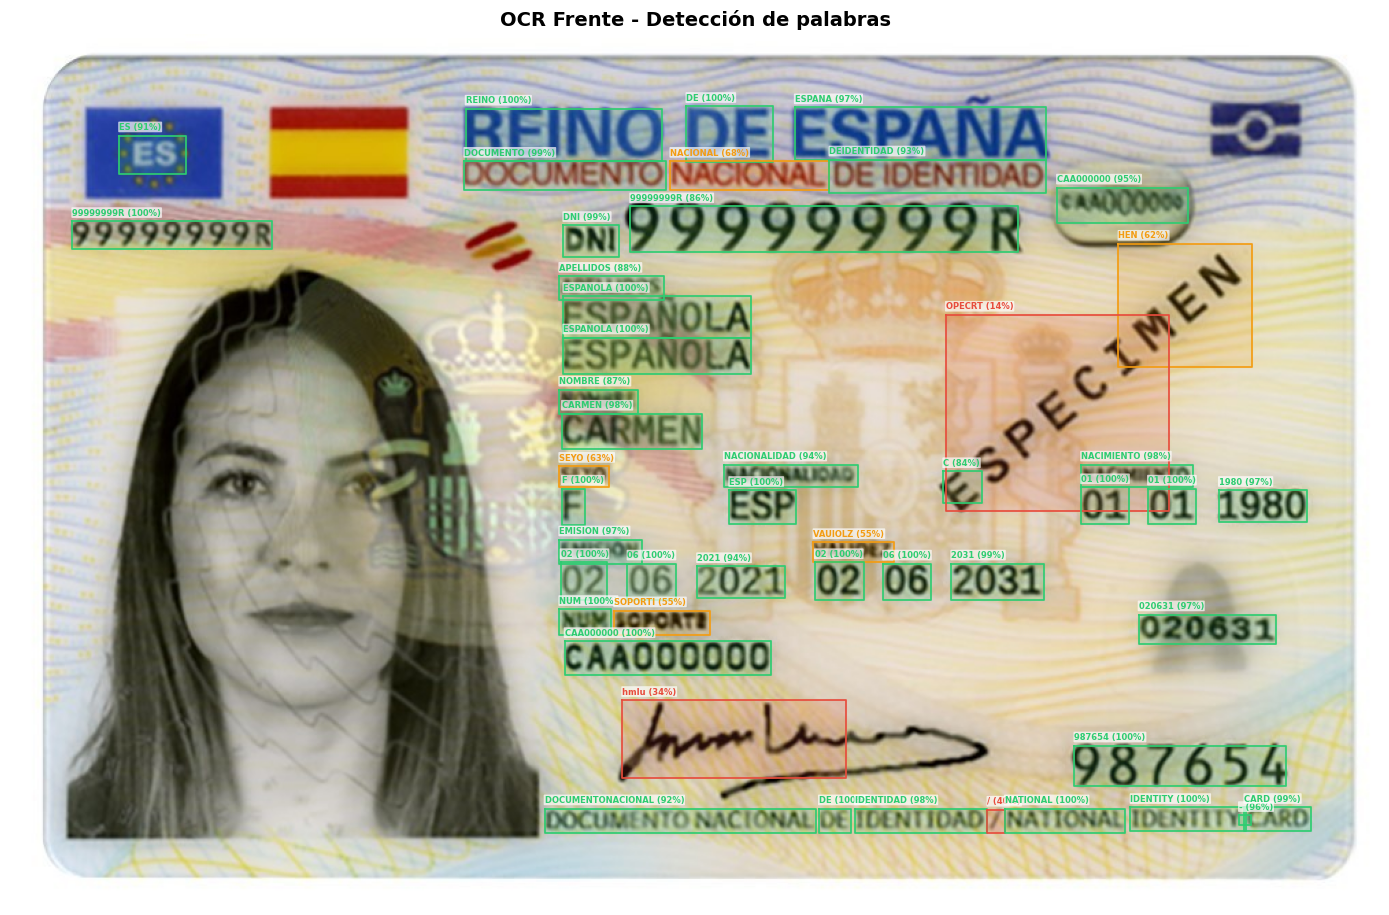

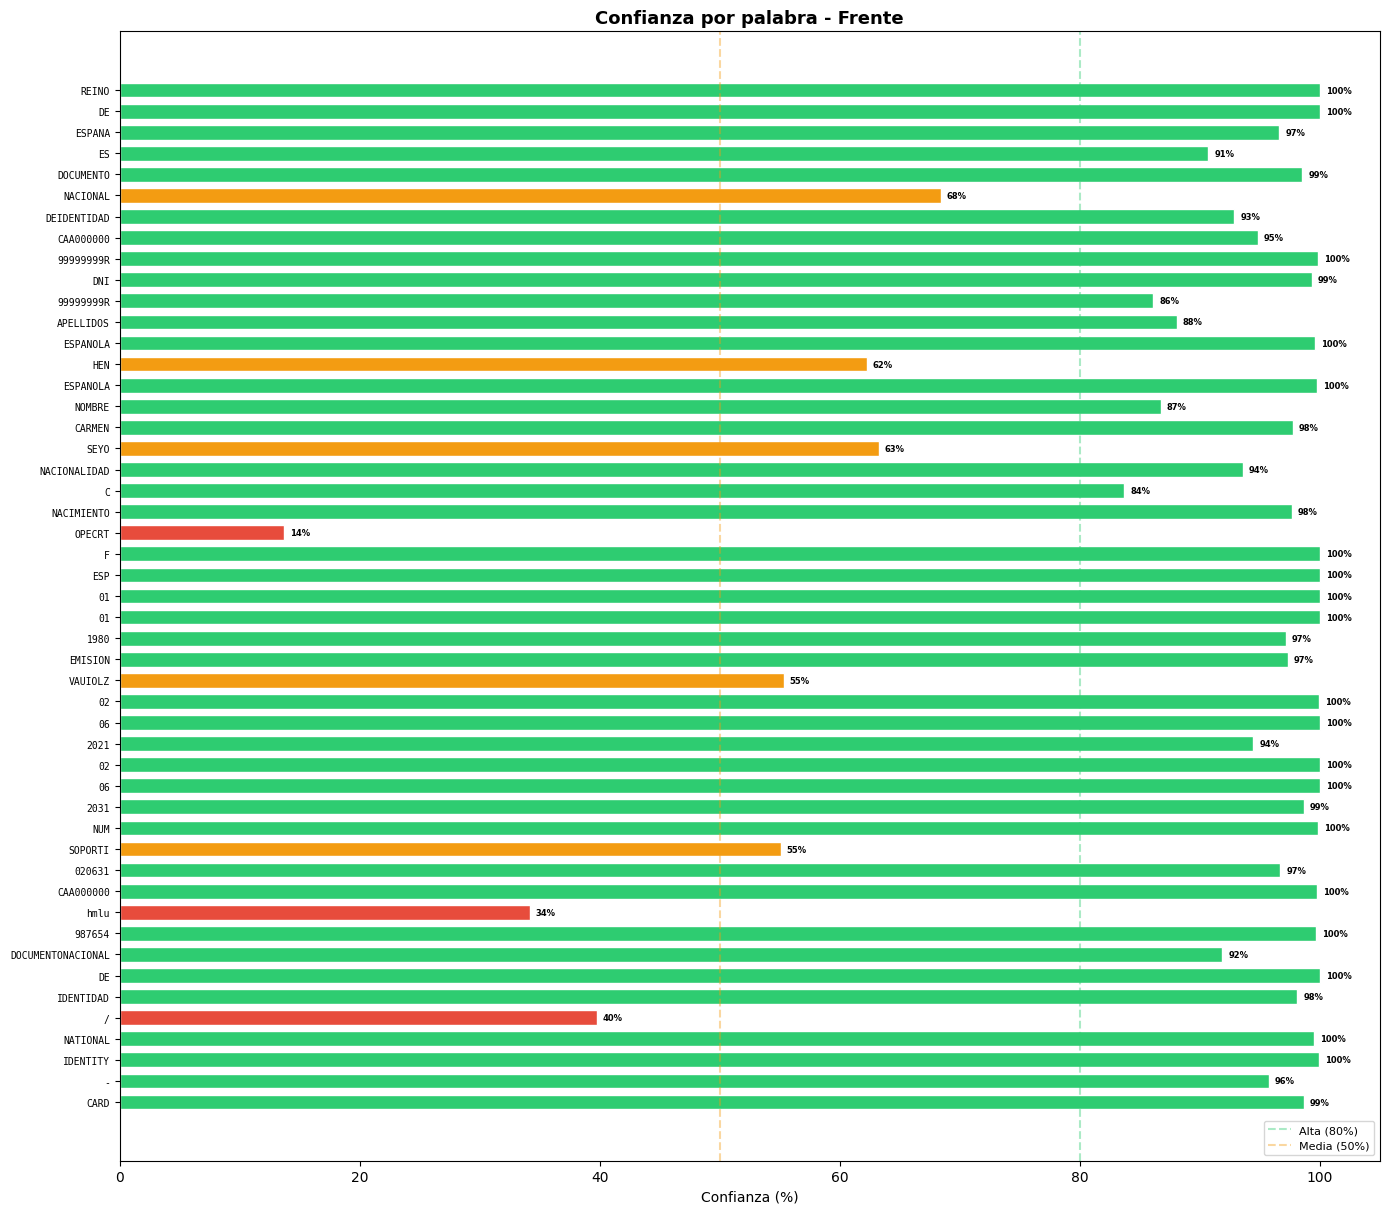

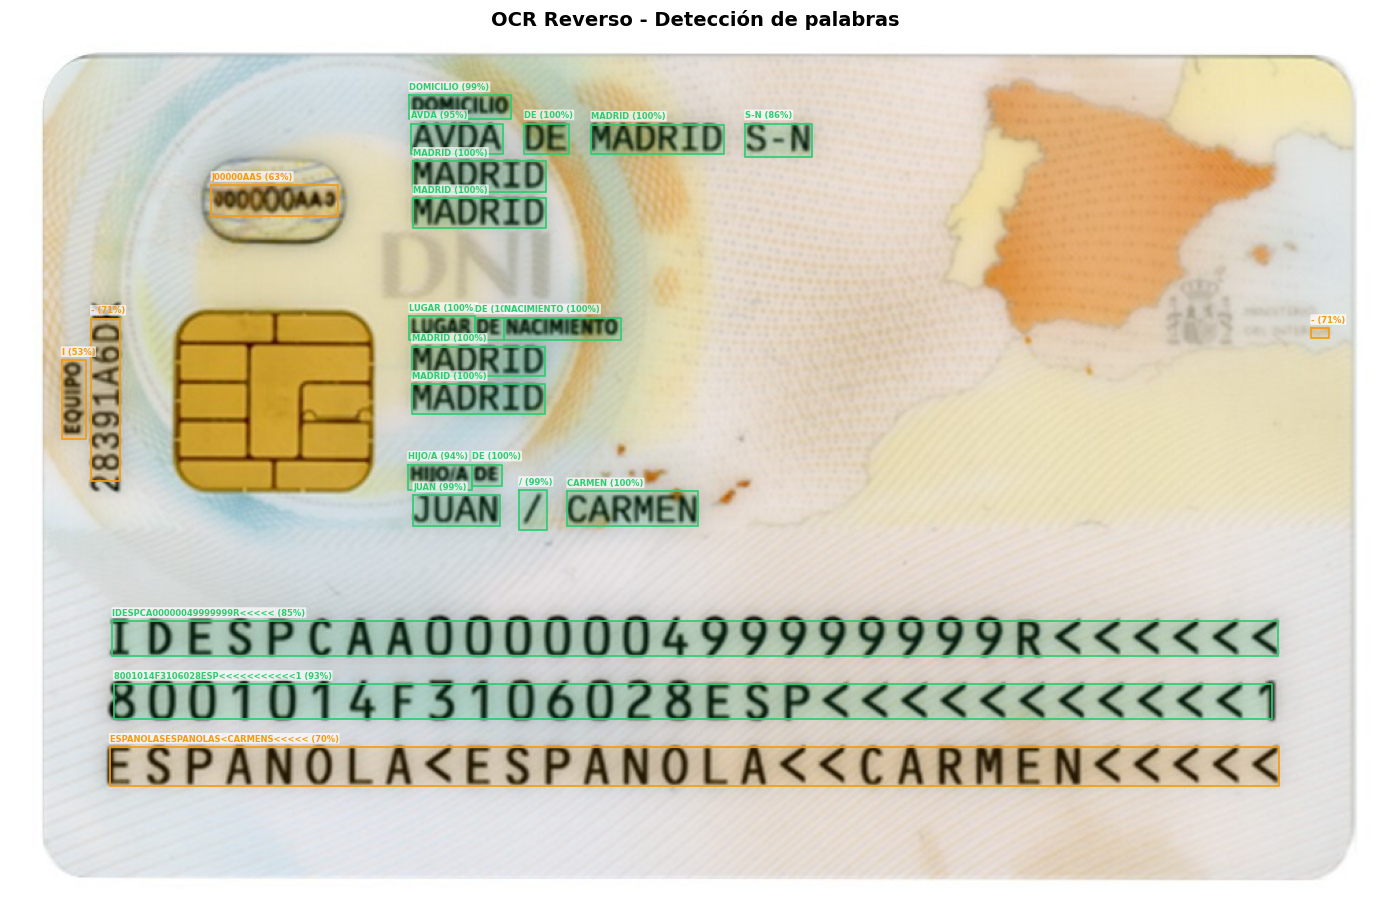

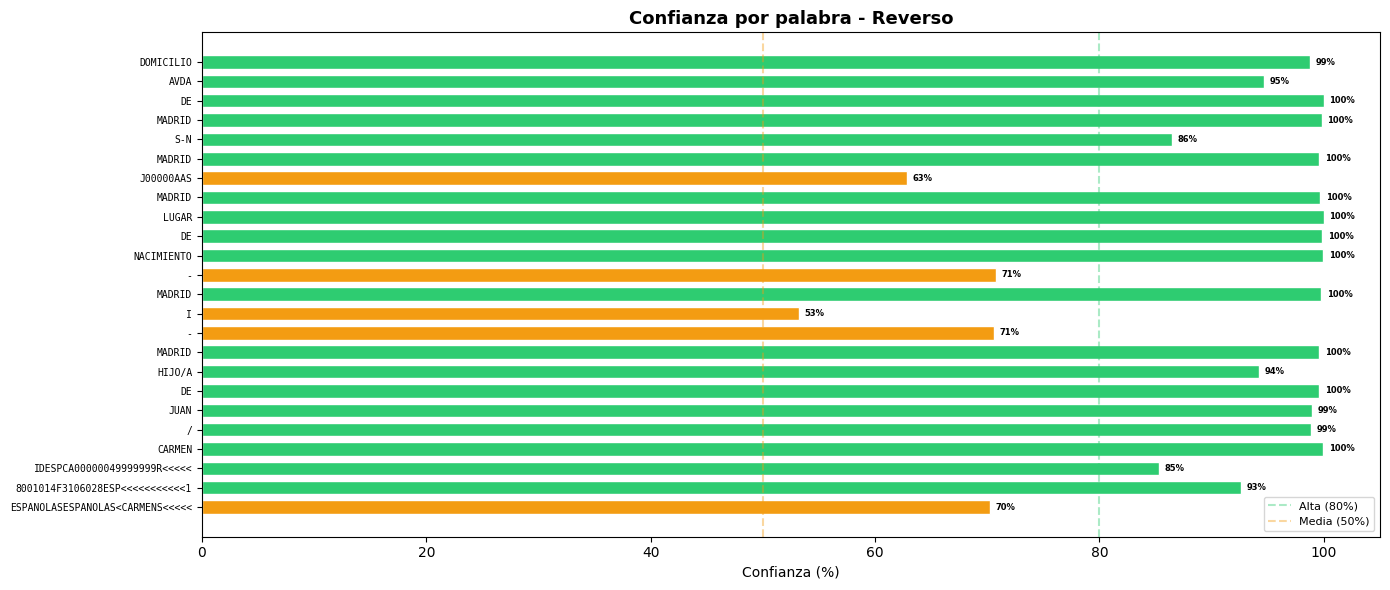


  RESULTADO DEL ANALISIS DNI

                       DATOS PERSONALES                     
  --------------------------------------------------------------
  Numero DNI:        99999999R
  Apellidos:         Espanola Espanola
  Nombre:            Carmen
  Nombre completo:   Carmen Espanola Espanola
  Sexo:              Femenino
  Nacionalidad:      ESP

                            FECHAS                          
  --------------------------------------------------------------
  Nacimiento:        01/01/1980
  Emision:           02/06/2021
  Expiracion:        02/06/2031

                      DATOS ADICIONALES                     
  --------------------------------------------------------------
  Domicilio:         AVDA DE MADRID S-N, MADRID
  Lugar nacim.:      MADRID
  Hijo/a de:         JUAN / CARMEN
  N. Soporte:        CAA000000

                             MRZ                            
  --------------------------------------------------------------
  Tipo:              ID
 

In [610]:
dni = process_dni('dni_front_especimen.jpg', 'dni_back_especimen.jpg')
display(dni)

# JSON
print(f"JSON:\n{SEP}")
print(json.dumps({
    'personal': {k: getattr(dni, k) for k in
                 ['dni_number','surname','given_names','full_name','sex','nationality']},
    'dates': {k: getattr(dni, k) for k in ['birth_date','issue_date','expiry_date']},
    'address': {k: getattr(dni, k) for k in ['domicilio','lugar_nacimiento','padres']},
    'document': {
        'support_number': dni.support_number,
        'mrz_detected': dni.mrz is not None,
        'mrz_checksums_valid': dni.mrz.all_checksums_valid if dni.mrz else False,
        'mrz_lines': dni.mrz.raw_lines if dni.mrz else [],
    },
    'quality': {
        'dni_letter_valid': dni.dni_letter_valid,
        'document_expired': dni.document_expired,
        'days_to_expiry': dni.days_to_expiry,
        'data_completeness': round(dni.data_completeness, 1),
        'quality_score': round(dni.quality_score, 1),
        'risk_flags': dni.risk_flags,
    },
}, indent=2, ensure_ascii=False))